# BENCHMARKER

This ipynb is made for visualizing "RECALL@K" and "Trade-Offs" of the core search engine built in folder 'core-engine'

## Pre-requisties 

- Creating Samples(50K Size)
- Cleaning The Data
- Running Linear Search for baseline

In [3]:
import sys
import os

# Get the absolute path of the parent directory (the 'searchis' root)
parent_dir = os.path.abspath('..')

# Add the parent directory to Python's module search path
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [4]:
from core_engine.main import run_sanitization_stage,run_vector_stage_faiss
from sentence_transformers import SentenceTransformer
import json
import numpy as np
import torch
import random

/home/rahul/searchis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Sampling a Small Dataset(50K) documents

Same dataset "ArXiv" just smaller

input.json = "./core-engine/archive/arxiv-metadata-oai-snapshot.json"

output.json = "./dataset/raw-data.json"

Ran Linux command "head -n 50000 input.json > output.json" to sample first 50K documents


### Sanitizing the Raw-Data for further use


In [5]:
raw_data_path = "/home/rahul/searchis/benchmarks/dataset/raw-data.json"
sanitized_path="/home/rahul/searchis/benchmarks/dataset/sanitized-data.json"

In [ ]:
%%time
run_sanitization_stage(raw_data_path,sanitized_path)

Starting data sanitization...
  ...sanitized 50000 documents.
Success! Processed and cleaned 50000 papers.
CPU times: user 1.79 s, sys: 36.9 ms, total: 1.82 s
Wall time: 1.83 s


### Creating Queries and Doc_ids List

In [6]:
queries = []
doc_ids = []
size_query = 500
with open(sanitized_path,"r") as f:
    counter = 0
    for line in f:
        try:
            record = json.loads(line)
        except json.JSONDecodeError:
            continue #Skip broken lines
        doc_ids.append(record.get("id"))

random_ids = set(np.random.choice(doc_ids, size=size_query, replace=False))

with open(sanitized_path,"r") as f:
    counter = 0
    for line in f:
        try:
            record = json.loads(line)
        except json.JSONDecodeError:
            continue #Skip broken lines
        doc_id = record.get("id")
        if doc_id in random_ids:
            queries.append(record.get("clean_abstract"))
            if len(queries)== size_query:
                break


### Running a Linear Search Algorithm (Ground Truth)

The results of this search algo will work as source of truth or baseline for every other implementation

In [7]:
def generate_ground_truth(sanitized_path: str, output_path: str, num_queries: int = 500, top_k: int = 10):
    """
    Generates a ground truth dataset by running a brute-force exact linear scan.
    
    Encodes all documents fresh from the sanitized data using the same SentenceTransformer
    model, then computes exact cosine similarity via matrix multiplication.
    """
    import gc
    
    # Load the same model used by the FAISS indexer for consistency
    model_name = "all-MiniLM-L6-v2"
    print(f"Loading SentenceTransformer model: {model_name}...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = SentenceTransformer(model_name, device=device)
    
    # Read all documents and encode them to get exact (non-quantized) embeddings
    print(f"Reading documents from {sanitized_path}...")
    doc_ids = []
    texts = []
    with open(sanitized_path, "r") as f:
        for line in f:
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue
            doc_ids.append(record.get("id"))
            full_text = record.get("clean_title", "") + ". " + record.get("clean_abstract", "")
            texts.append(full_text.strip())
    
    total_docs = len(doc_ids)
    print(f"Read {total_docs} documents. Encoding embeddings...")
    
    # Encode all documents with normalized embeddings (same as FAISS indexer)
    embeddings = model.encode(
        texts,
        show_progress_bar=True,
        normalize_embeddings=True,
        batch_size=256,
    )
    
    # Free text data from memory
    del texts
    gc.collect()
    
    # Move to PyTorch tensors for fast matrix multiplication
    pt_device = torch.device(device)
    embeddings = torch.from_numpy(embeddings).to(pt_device)
    
    if num_queries > total_docs:
        num_queries = total_docs
        
    print(f"Randomly selecting {num_queries} synthetic queries...")
    # Pick random document indices to act as our test queries
    query_indices = random.sample(range(total_docs), num_queries)
    
    query_embeddings = embeddings[query_indices]
    query_ids = [doc_ids[i] for i in query_indices]
    
    # Embeddings are already L2-normalized from encode(), so dot product = cosine similarity
    print("Computing exact brute-force cosine similarity (The O(N) linear scan)...")
    # [num_queries, 384] @ [384, total_docs] -> [num_queries, total_docs] matrix of scores.
    similarity_matrix = torch.matmul(query_embeddings, embeddings.T)
    
    # We fetch top_k + 1 because the #1 closest document to the query will always be the query itself!
    print(f"Extracting the absolute Top {top_k} nearest neighbors...")
    top_scores, top_indices = torch.topk(similarity_matrix, k=top_k + 1, dim=1)
    
    ground_truth = {}
    
    # Move indices back to CPU for normal Python processing
    top_indices = top_indices.cpu().numpy()
    
    for i, query_id in enumerate(query_ids):
        neighbors = []
        # Iterate over the top K+1 indices
        for idx in top_indices[i]:
            neighbor_id = doc_ids[idx]
            
            # Skip the query document itself (we don't want it in the search results)
            if neighbor_id == query_id:
                continue
                
            neighbors.append(str(neighbor_id)) 
            
            # Stop once we have exactly top_k true neighbors
            if len(neighbors) == top_k:
                break
                
        # Store in our dictionary
        ground_truth[str(query_id)] = neighbors
        
    print(f"Saving ground truth to {output_path}...")
    with open(output_path, 'w') as f:
        json.dump(ground_truth, f, indent=4)
        
    print("Ground truth generation complete! You can now use this to test your LSH/FAISS recall.")


#### Ran this on Google Colab T4 GPU 
 `generate_ground_path(sanitized_path,vectored_path_faiss)`

## Custom Lexical Search Engine


### Tokenizing The data

In [7]:
from core_engine.main import run_tokenization_stage
tokenized_path = "./dataset/tokenized-data.json"

In [11]:
%%time
run_tokenization_stage(sanitized_path,tokenized_path)

Starting Tokenization...
  ...tokenized 50000 documents.
Success! Output File Path:-./dataset/tokenized-data.json 
CPU times: user 6.71 s, sys: 50.7 ms, total: 6.77 s
Wall time: 6.8 s


### Indexing The Tokenized Data

In [8]:
from core_engine.main import run_indexation_stage
inverted_indexed_path = "./dataset/inverted-indices.json"

In [13]:
%%time
run_indexation_stage(tokenized_path,inverted_indexed_path)

Starting Indexing.....
  ...indexed 50000 documents.
  Packing remaining in-memory postings...
  Writing to ./dataset/inverted-indices.json.tmp (~0.0 GB)...
  ✓ Index saved: 50,000 docs, 131,074 terms, 2,617,478 postings, 20.3 MB on disk.
Successfully Indexed:50000 documents
CPU times: user 4.5 s, sys: 170 ms, total: 4.67 s
Wall time: 4.69 s


### Lexical-Search

Search was done from file `multiprocessor.py` it was specially optimize to work with all avaible CPU cores
,since Jupyter Notebooks cannot do that

In [12]:
with open("./dataset/final_recall_lexical.json","r") as f:
    recall_list = json.load(f)
recall_list = [(recall,k1,round(b,1)) for recall,k1,b in recall_list]
print(recall_list[:10])

[(0.4, 0.5, 0.2), (0.7, 0.5, 0.2), (0.3, 0.5, 0.2), (0.4, 0.5, 0.2), (0.0, 0.5, 0.2), (0.9, 0.5, 0.2), (0.5, 0.5, 0.2), (0.2, 0.5, 0.2), (0.6, 0.5, 0.2), (0.4, 0.5, 0.2)]


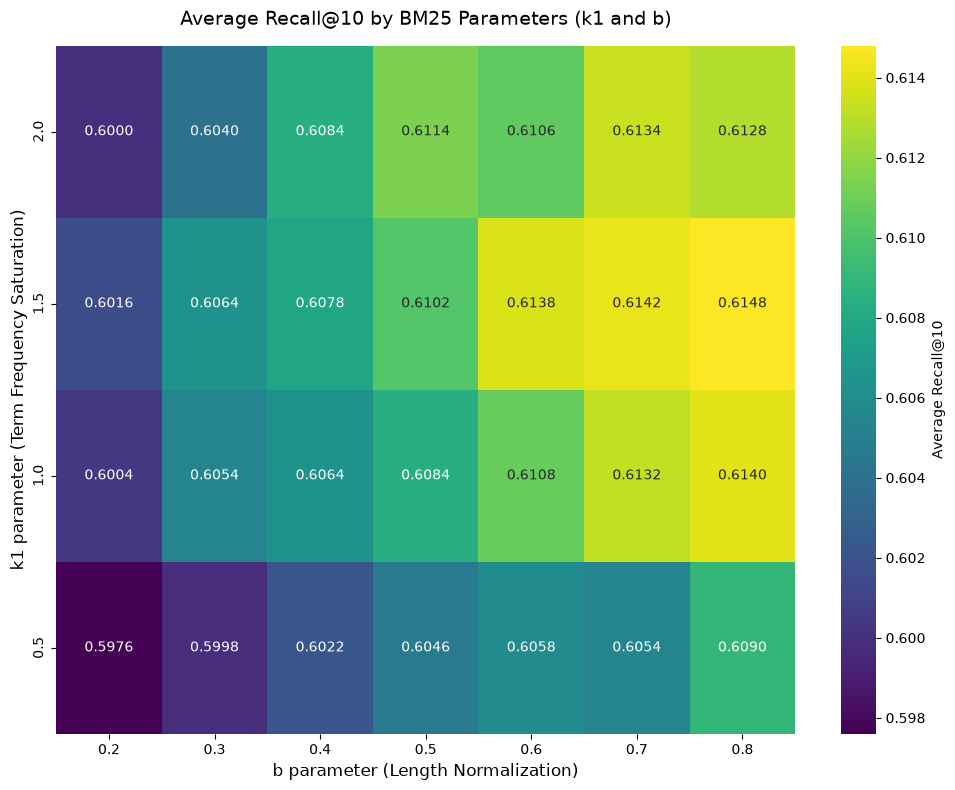

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(recall_list, columns=['Recall', 'k1', 'b'])


avg_recall_df = df.groupby(['k1', 'b'])['Recall'].mean().reset_index()


# Rows = k1, Columns = b, Values = Average Recall
heatmap_data = avg_recall_df.pivot(index='k1', columns='b', values='Recall')

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap='viridis', 
    fmt=".4f", # Formats the numbers to 4 decimal places
    cbar_kws={'label': 'Average Recall@10'}
)

plt.title('Average Recall@10 by BM25 Parameters (k1 and b)', fontsize=14, pad=15)
plt.xlabel('b parameter (Length Normalization)', fontsize=12)
plt.ylabel('k1 parameter (Term Frequency Saturation)', fontsize=12)

# Invert Y-axis so the lowest k1 value starts at the bottom (optional but standard)
plt.gca().invert_yaxis()

# 7. Render the plot
plt.tight_layout()
plt.show()